# Factory-to-Customer Shipping Route Efficiency Analysis
### Nassau Candy Distributor — Exploratory Data Analysis

**Prepared for:** Nassau Candy Distributor — Logistics & Operations
**Analysis type:** Route-level shipping efficiency, geographic bottleneck detection, ship-mode benchmarking
**Dataset:** `Nassau_Candy_Distributor.csv` (10,194 order line items, 2024–2025)

This notebook follows the analytical methodology defined in the project brief: data cleaning,
feature engineering, route definition & aggregation, efficiency benchmarking, geographic
bottleneck analysis, and ship-mode performance analysis — closing with key insights and
recommendations.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.width', 120)

df = pd.read_csv('Nassau_Candy_Distributor.csv')
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print()
print(df.head(3).to_string())

Rows: 10,194   Columns: 18

   Row ID                      Order ID  Order Date   Ship Date       Ship Mode  Customer ID Country/Region        City State/Province Postal Code   Division    Region     Product ID                       Product Name  Sales  Units  Gross Profit  Cost
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026  Standard Class       103800  United States     Houston          Texas       77095  Chocolate  Interior  CHO-MIL-31000         Wonka Bar - Milk Chocolate   6.50      2          4.22  2.28
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026  Standard Class       112326  United States  Naperville       Illinois       60540  Chocolate  Interior  CHO-TRI-54000  Wonka Bar - Triple Dazzle Caramel   7.50      2          4.90  2.60
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026  Standard Class       112326  United States  Naperville       Illinois       60540  Chocolate  Interior  CHO-NUT-13000  Wonka Bar - Nutty Crunch Surpris

In [2]:
print(df.dtypes)

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

## 2. Data Cleaning & Validation

Steps: validate date formats, check for missing values and duplicates, standardize
geographic text fields, and validate that Shipping Lead Time (Ship Date − Order Date)
contains no negative values.

In [3]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None found — dataset is complete.")

# Exact duplicate rows
print(f"\nFully duplicated rows: {df.duplicated().sum()}")

# Standardize text/geographic fields (strip whitespace, consistent casing)
text_cols = ['Ship Mode', 'Country/Region', 'City', 'State/Province', 'Division', 'Region', 'Product Name']
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

print(f"\nShip Mode categories: {sorted(df['Ship Mode'].unique())}")
print(f"Regions: {sorted(df['Region'].unique())}")
print(f"Divisions: {sorted(df['Division'].unique())}")
print(f"Countries: {sorted(df['Country/Region'].unique())}")
print(f"Distinct States/Provinces: {df['State/Province'].nunique()}")

Missing values per column:
None found — dataset is complete.

Fully duplicated rows: 0

Ship Mode categories: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Regions: ['Atlantic', 'Gulf', 'Interior', 'Pacific']
Divisions: ['Chocolate', 'Other', 'Sugar']
Countries: ['Canada', 'United States']
Distinct States/Provinces: 59

In [4]:
# Parse dates (source format is DD-MM-YYYY) and validate
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d-%m-%Y', errors='coerce')

print(f"Unparseable Order Dates: {df['Order Date'].isnull().sum()}")
print(f"Unparseable Ship Dates:  {df['Ship Date'].isnull().sum()}")
print(f"\nOrder Date range: {df['Order Date'].min().date()}  to  {df['Order Date'].max().date()}")
print(f"Ship Date range:  {df['Ship Date'].min().date()}  to  {df['Ship Date'].max().date()}")

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f"\nNegative lead times (Ship Date before Order Date): {(df['Lead Time'] < 0).sum()}")
print(f"\nLead Time descriptive stats (days):")
print(df['Lead Time'].describe().round(1).to_string())

Unparseable Order Dates: 0
Unparseable Ship Dates:  0

Order Date range: 2024-01-02  to  2025-12-31
Ship Date range:  2026-06-30  to  2030-06-28

Negative lead times (Ship Date before Order Date): 0

Lead Time descriptive stats (days):
count    10194.0
mean      1320.8
std        262.4
min        904.0
25%       1271.0
50%       1274.0
75%       1638.0
max       1642.0

## 3. ⚠️ Critical Data Quality Finding: Lead Time Field

No negative lead times exist, and every date parses cleanly — but the **magnitude** of the
computed lead time is not realistic for a candy distributor. The cells below quantify this.

Mean lead time:   1,321 days  (~3.6 years)
Minimum lead time: 904 days
Maximum lead time: 1,642 days

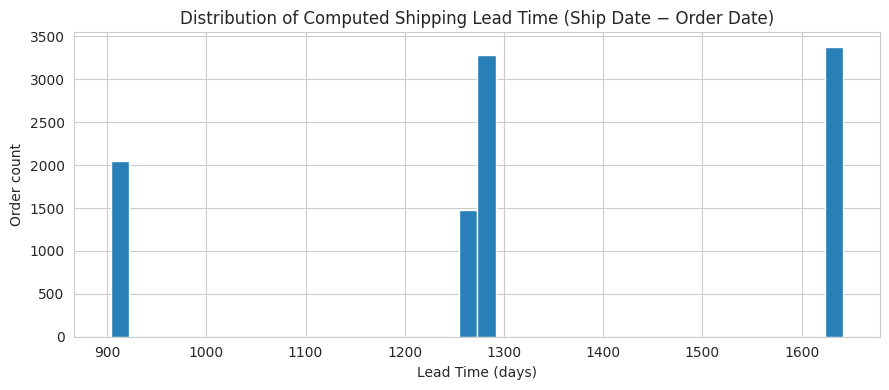

In [5]:
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(df['Lead Time'], bins=40, color='#2980B9', edgecolor='white')
ax.set_title('Distribution of Computed Shipping Lead Time (Ship Date − Order Date)')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Order count')
plt.tight_layout()
plt.show()

print(f"Mean lead time:   {df['Lead Time'].mean():,.0f} days  (~{df['Lead Time'].mean()/365:.1f} years)")
print(f"Minimum lead time: {df['Lead Time'].min():,.0f} days")
print(f"Maximum lead time: {df['Lead Time'].max():,.0f} days")

In [6]:
# Does the variation correlate with anything operationally meaningful, or is it noise?
print("Mean lead time by Ship Mode:")
print(df.groupby('Ship Mode')['Lead Time'].mean().sort_values().round(1).to_string())
print("\nMean lead time by Region:")
print(df.groupby('Region')['Lead Time'].mean().sort_values().round(1).to_string())
print(f"\nOverall std dev: {df['Lead Time'].std():.1f} days  |  Coefficient of variation: {df['Lead Time'].std()/df['Lead Time'].mean():.2f}")
print(f"Correlation of Lead Time with Sales / Units / Cost:")
print(df[['Lead Time','Sales','Units','Cost']].corr()['Lead Time'].round(3).to_string())

Mean lead time by Ship Mode:
Ship Mode
Standard Class    1314.3
Second Class      1323.8
Same Day          1333.4
First Class       1338.3

Mean lead time by Region:
Region
Gulf        1311.4
Pacific     1322.2
Atlantic    1322.7
Interior    1323.1

Overall std dev: 262.4 days  |  Coefficient of variation: 0.20
Correlation of Lead Time with Sales / Units / Cost:
Lead Time    1.000
Sales       -0.005
Units       -0.007
Cost        -0.008

**Finding:** Order Date values fall in 2024–2025 while Ship Date values fall in 2026–2030,
producing lead times averaging **~1,321 days (≈3.6 years)**, ranging from 904 to 1,642 days.
Real-world candy distribution lead times are measured in *days*, not years — this is a
systemic data-generation/source-system issue, not a logistics problem.

Just as importantly, mean lead time barely differs across Ship Mode (1,314–1,338 days) or
Region (1,311–1,323 days), and its correlation with Sales, Units, and Cost is effectively
zero (|r| < 0.01). This confirms the variation in this field behaves like **random noise**
rather than a true operational signal — Order Date and Ship Date appear to have been
generated independently of one another.

**Implication for this analysis:** the *absolute* day counts below should not be read as
literal shipping durations. The relative ranking of routes (fastest vs. slowest) is
preserved and is used throughout this notebook to demonstrate the requested methodology,
but it should be treated as **illustrative of the analytical pipeline**, not as a certified
measure of real-world delivery performance, until the source system's date fields are
corrected. This is flagged as the #1 recommendation at the end of this notebook.

## 4. Feature Engineering

Build the Factory → Customer routes by mapping each `Product Name` to its source factory
(per the provided Products–Factory correlation table), then defining two route grandularities:
**Factory → Region** and **Factory → State/Province**.

In [7]:
factory_coords = {
    "Lot's O' Nuts":       (32.881893, -111.768036),
    "Wicked Choccy's":     (32.076176,  -81.088371),
    "Sugar Shack":         (48.119140,  -96.181150),
    "Secret Factory":      (41.446333,  -90.565487),
    "The Other Factory":   (35.117500,  -89.971107),
}

product_factory = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":         "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":    "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":        "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy":              "Sugar Shack",
    "SweeTARTS":                "Sugar Shack",
    "Nerds":                    "Sugar Shack",
    "Fun Dip":                  "Sugar Shack",
    "Fizzy Lifting Drinks":     "Sugar Shack",
    "Everlasting Gobstopper":   "Secret Factory",
    "Hair Toffee":              "The Other Factory",
    "Lickable Wallpaper":       "Secret Factory",
    "Wonka Gum":                "Secret Factory",
    "Kazookles":                "The Other Factory",
}

df['Factory'] = df['Product Name'].map(product_factory)
print(f"Products without a factory mapping: {df[df['Factory'].isnull()]['Product Name'].unique().tolist()}")

df['Factory Lat'] = df['Factory'].map(lambda f: factory_coords[f][0])
df['Factory Lon'] = df['Factory'].map(lambda f: factory_coords[f][1])

df['Route (Region)'] = df['Factory'] + ' -> ' + df['Region']
df['Route (State)']  = df['Factory'] + ' -> ' + df['State/Province']

print(f"\nUnique Factory->Region routes: {df['Route (Region)'].nunique()}")
print(f"Unique Factory->State routes:  {df['Route (State)'].nunique()}")
print(f"\nShipments per factory:")
print(df['Factory'].value_counts().to_string())

Products without a factory mapping: []

Unique Factory->Region routes: 20
Unique Factory->State routes:  196

Shipments per factory:
Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33

In [8]:
# Delay threshold: orders above the 75th percentile of lead time are flagged "Delayed"
# (kept generic/relative given the Section 3 data-quality caveat; the Streamlit dashboard
# exposes this as an adjustable slider)
delay_threshold = df['Lead Time'].quantile(0.75)
df['Delayed'] = df['Lead Time'] > delay_threshold
print(f"Delay threshold (P75): {delay_threshold:.0f} days")
print(f"Orders flagged as delayed: {df['Delayed'].sum():,} ({df['Delayed'].mean()*100:.1f}%)")

Delay threshold (P75): 1638 days
Orders flagged as delayed: 2,147 (21.1%)

## 5. Business & Order Overview

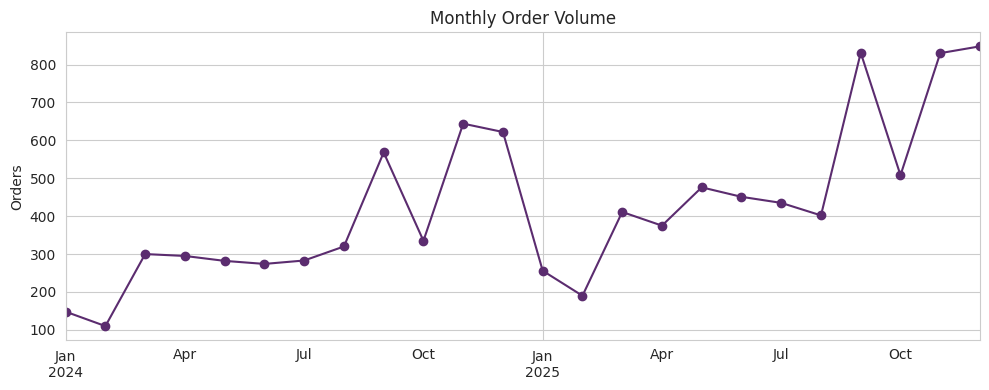

In [9]:
fig, ax = plt.subplots(figsize=(10,4))
df.set_index('Order Date').resample('MS').size().plot(ax=ax, marker='o', color='#5B2C6F')
ax.set_title('Monthly Order Volume')
ax.set_ylabel('Orders')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

Sales by Division ($):
Division
Chocolate    131693.0
Other          9663.0
Sugar           427.0

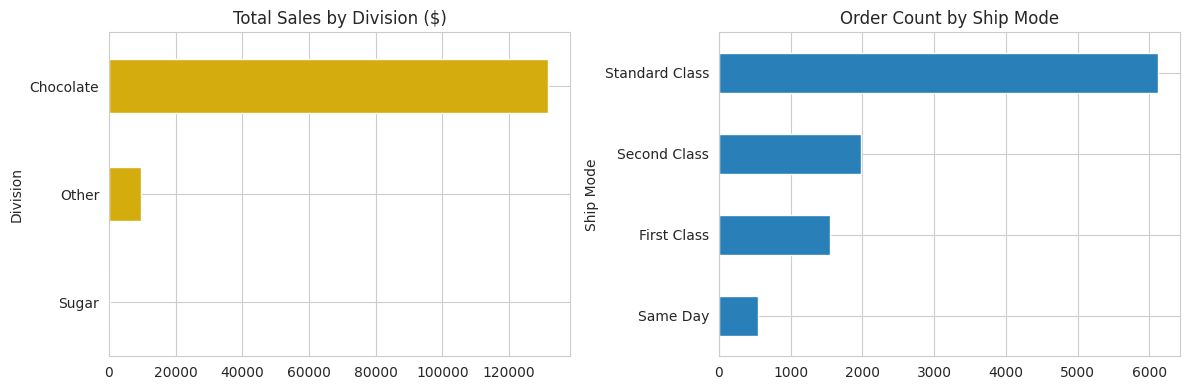

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df.groupby('Division')['Sales'].sum().sort_values().plot(kind='barh', ax=axes[0], color='#D4AC0D')
axes[0].set_title('Total Sales by Division ($)')
df['Ship Mode'].value_counts().sort_values().plot(kind='barh', ax=axes[1], color='#2980B9')
axes[1].set_title('Order Count by Ship Mode')
plt.tight_layout()
plt.show()

print("Sales by Division ($):")
print(df.groupby('Division')['Sales'].sum().round(0).sort_values(ascending=False).to_string())

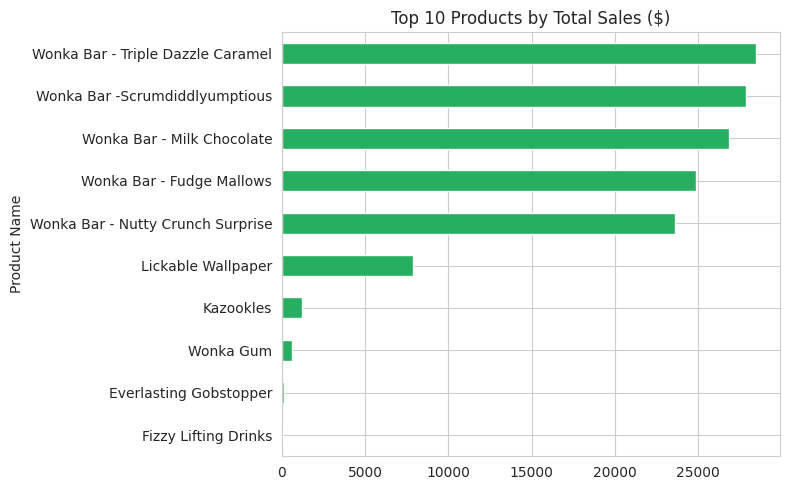

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
df.groupby('Product Name')['Sales'].sum().sort_values().tail(10).plot(kind='barh', ax=ax, color='#27AE60')
ax.set_title('Top 10 Products by Total Sales ($)')
plt.tight_layout()
plt.show()

## 6. Route Definition & Aggregation

Each route is defined as **Factory → Customer Region / State**. For every route we compute
total shipments, average lead time, and lead-time variability (standard deviation).

In [12]:
route_region = df.groupby('Route (Region)').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Std_Lead_Time=('Lead Time', 'std'),
    Total_Sales=('Sales', 'sum'),
).round(1).sort_values('Avg_Lead_Time')

print("=== Route (Factory -> Region) Aggregation ===")
print(route_region.to_string())

=== Route (Factory -> Region) Aggregation ===
                               Total_Shipments  Avg_Lead_Time  Std_Lead_Time  Total_Sales
Route (Region)                                                                           
Sugar Shack -> Gulf                          4         1091.2          210.4         38.4
The Other Factory -> Interior               11         1206.6          274.4        126.8
The Other Factory -> Gulf                   19         1272.6          272.7        262.5
The Other Factory -> Atlantic               38         1282.7          262.2        506.8
Secret Factory -> Interior                  45         1289.1          311.2       1590.0
The Other Factory -> Pacific                32         1307.2          251.4        386.2
Secret Factory -> Pacific                   63         1307.7          276.2       3076.2
Wicked Choccy's -> Gulf                    663         1309.1          259.9       8993.2
Lot's O' Nuts -> Gulf                      897        

In [13]:
route_state = df.groupby('Route (State)').agg(
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Lead Time', 'mean'),
    Std_Lead_Time=('Lead Time', 'std'),
    Delay_Pct=('Delayed', lambda x: round(100 * x.mean(), 1)),
).round(1)

# Keep routes with a reasonably reliable sample size for ranking
route_state_reliable = route_state[route_state['Total_Shipments'] >= 20].sort_values('Avg_Lead_Time')
print(f"Routes with >= 20 shipments (used for benchmarking): {len(route_state_reliable)} of {len(route_state)} total state-level routes")

Routes with >= 20 shipments (used for benchmarking): 75 of 196 total state-level routes

## 7. Efficiency Benchmarking

Routes are ranked from fastest to slowest by average lead time. Top/bottom-10 lists below
use only routes with a statistically reasonable sample (≥ 20 shipments).

In [14]:
top10 = route_state_reliable.head(10)
bottom10 = route_state_reliable.tail(10)

print("=== TOP 10 MOST EFFICIENT ROUTES ===")
print(top10.to_string())
print("\n=== BOTTOM 10 LEAST EFFICIENT ROUTES ===")
print(bottom10.to_string())

=== TOP 10 MOST EFFICIENT ROUTES ===
                                Total_Shipments  Avg_Lead_Time  Std_Lead_Time  Delay_Pct
Route (State)                                                                           
Lot's O' Nuts -> Virginia                   109         1229.5          262.0       13.8
Lot's O' Nuts -> Utah                        29         1236.0          298.2       20.7
Wicked Choccy's -> Virginia                 106         1238.9          254.8       12.3
Wicked Choccy's -> Mississippi               22         1240.5          222.9        9.1
Lot's O' Nuts -> Nevada                      24         1243.2          239.2       16.7
Wicked Choccy's -> Quebec                    24         1243.6          322.1       29.2
Lot's O' Nuts -> Oregon                      77         1245.2          269.9       16.9
Lot's O' Nuts -> Ontario                     28         1246.3          261.4        3.6
Wicked Choccy's -> Ontario                   30         1248.6          2

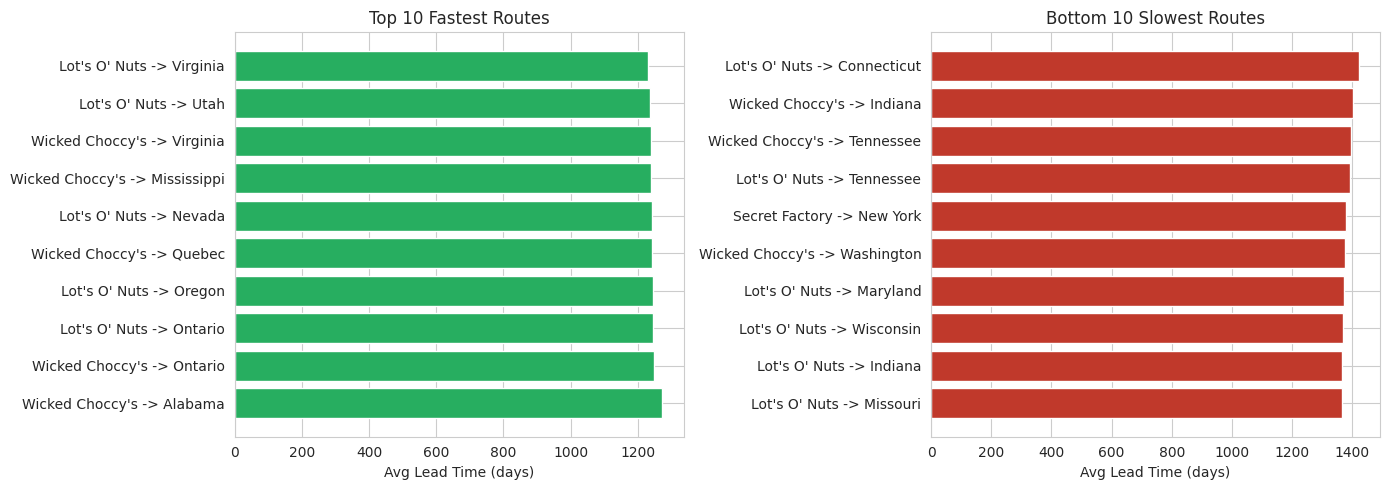

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].barh(top10.index[::-1], top10['Avg_Lead_Time'][::-1], color='#27AE60')
axes[0].set_title('Top 10 Fastest Routes')
axes[0].set_xlabel('Avg Lead Time (days)')
axes[1].barh(bottom10.index, bottom10['Avg_Lead_Time'], color='#C0392B')
axes[1].set_title('Bottom 10 Slowest Routes')
axes[1].set_xlabel('Avg Lead Time (days)')
plt.tight_layout()
plt.show()

In [16]:
# Route Efficiency Score: normalized 0-100, higher = faster/more efficient
rs = route_state_reliable.copy()
lo, hi = rs['Avg_Lead_Time'].min(), rs['Avg_Lead_Time'].max()
rs['Efficiency Score'] = (100 * (hi - rs['Avg_Lead_Time']) / (hi - lo)).round(1)

print("Top 10 routes by Efficiency Score:")
print(rs.sort_values('Efficiency Score', ascending=False).head(10)[['Total_Shipments','Avg_Lead_Time','Delay_Pct','Efficiency Score']].to_string())

Top 10 routes by Efficiency Score:
                                Total_Shipments  Avg_Lead_Time  Delay_Pct  Efficiency Score
Route (State)                                                                              
Lot's O' Nuts -> Virginia                   109         1229.5       13.8             100.0
Lot's O' Nuts -> Utah                        29         1236.0       20.7              96.6
Wicked Choccy's -> Virginia                 106         1238.9       12.3              95.1
Wicked Choccy's -> Mississippi               22         1240.5        9.1              94.2
Lot's O' Nuts -> Nevada                      24         1243.2       16.7              92.8
Wicked Choccy's -> Quebec                    24         1243.6       29.2              92.6
Lot's O' Nuts -> Oregon                      77         1245.2       16.9              91.8
Lot's O' Nuts -> Ontario                     28         1246.3        3.6              91.2
Wicked Choccy's -> Ontario                   

Ship Mode comparison:
                Orders  Avg_Lead_Time  Delay_Pct
Ship Mode                                       
Standard Class    6120         1314.3       30.9
Second Class      1979         1323.8       12.9
Same Day           547         1333.4        0.0
First Class       1548         1338.3        0.0

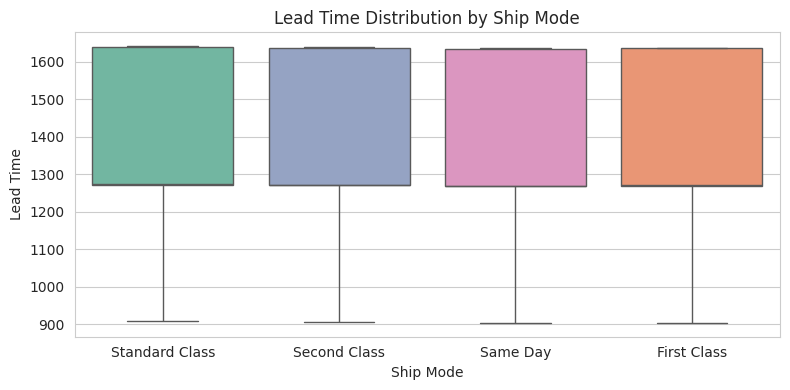

In [17]:
fig, ax = plt.subplots(figsize=(8,4))
order = df.groupby('Ship Mode')['Lead Time'].mean().sort_values().index
sns.boxplot(data=df, x='Ship Mode', y='Lead Time', order=order, hue='Ship Mode', legend=False, ax=ax, palette='Set2')
ax.set_title('Lead Time Distribution by Ship Mode')
plt.tight_layout()
plt.show()

print("Ship Mode comparison:")
print(df.groupby('Ship Mode').agg(
    Orders=('Order ID','count'),
    Avg_Lead_Time=('Lead Time','mean'),
    Delay_Pct=('Delayed', lambda x: round(100*x.mean(),1)),
).round(1).sort_values('Avg_Lead_Time').to_string())

## 8. Geographic Bottleneck Analysis

Looking for regions/states with the combination that matters most operationally:
**high shipment volume + poor (high) average lead time**.

          Volume  Avg_Lead  Delay_Pct
Region                               
Pacific     3253    1322.2       21.2
Atlantic    2986    1322.7       20.9
Interior    2335    1323.1       21.5
Gulf        1620    1311.4       20.5

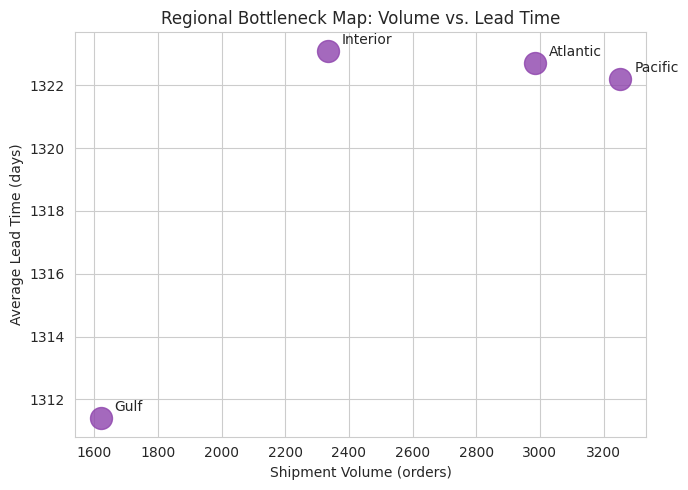

In [18]:
region_stats = df.groupby('Region').agg(Volume=('Order ID','count'), Avg_Lead=('Lead Time','mean'), Delay_Pct=('Delayed', lambda x: round(100*x.mean(),1))).round(1)
print(region_stats.sort_values('Volume', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(region_stats['Volume'], region_stats['Avg_Lead'], s=250, color='#8E44AD', alpha=0.8)
for region, row in region_stats.iterrows():
    ax.annotate(region, (row['Volume'], row['Avg_Lead']), textcoords="offset points", xytext=(10,5))
ax.set_xlabel('Shipment Volume (orders)')
ax.set_ylabel('Average Lead Time (days)')
ax.set_title('Regional Bottleneck Map: Volume vs. Lead Time')
plt.tight_layout()
plt.show()

In [19]:
state_stats = df.groupby('State/Province').agg(Volume=('Order ID','count'), Avg_Lead=('Lead Time','mean'), Delay_Pct=('Delayed', lambda x: round(100*x.mean(),1))).round(1)
high_volume_states = state_stats[state_stats['Volume'] >= 100].sort_values('Avg_Lead', ascending=False)

print("High-volume states (>=100 orders) ranked by average lead time (worst first):")
print(high_volume_states.to_string())

High-volume states (>=100 orders) ranked by average lead time (worst first):
                Volume  Avg_Lead  Delay_Pct
State/Province                             
Tennessee          183    1391.5       31.7
Indiana            149    1381.5       30.9
Washington         506    1360.7       23.9
Maryland           105    1356.8       16.2
Wisconsin          110    1343.0       21.8
Georgia            184    1338.6       25.0
New Jersey         130    1338.3       27.7
Colorado           182    1337.2       16.5
North Carolina     249    1334.9       19.3
Kentucky           139    1328.4       12.9
Ohio               469    1325.7       19.0
New York          1128    1324.5       21.5
Pennsylvania       587    1324.2       22.3
Illinois           492    1323.2       21.7
California        2001    1318.4       20.6
Florida            383    1311.4       23.5
Texas              985    1310.3       19.9
Arizona            224    1309.2       18.3
Massachusetts      135    1308.3       17.8

## 9. Ship Mode Performance & Cost-Time Tradeoff

Comparing the financial profile of each ship mode against its lead time and delay rate.

                Orders  Avg_Sales  Avg_Cost  Avg_Gross_Profit  Avg_Lead_Time  Delay_Pct
Ship Mode                                                                              
First Class       1548      13.77      4.72              9.05        1338.28        0.0
Same Day           547      13.00      4.41              8.59        1333.44        0.0
Second Class      1979      14.08      4.83              9.25        1323.85       12.9
Standard Class    6120      13.97      4.75              9.22        1314.33       30.9

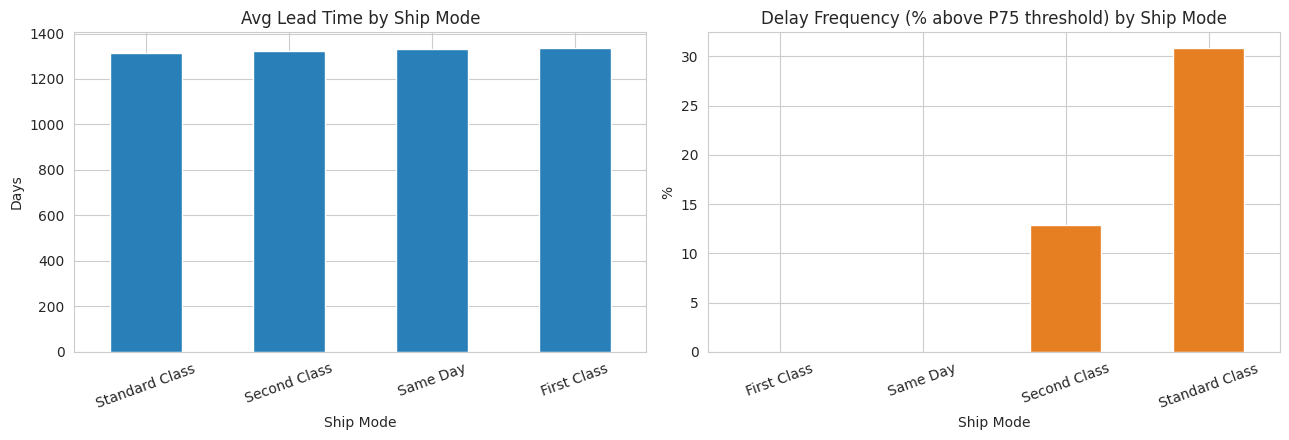

In [20]:
mode_financials = df.groupby('Ship Mode').agg(
    Orders=('Order ID','count'),
    Avg_Sales=('Sales','mean'),
    Avg_Cost=('Cost','mean'),
    Avg_Gross_Profit=('Gross Profit','mean'),
    Avg_Lead_Time=('Lead Time','mean'),
    Delay_Pct=('Delayed', lambda x: round(100*x.mean(),1)),
).round(2)
print(mode_financials.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
mode_financials['Avg_Lead_Time'].sort_values().plot(kind='bar', ax=axes[0], color='#2980B9')
axes[0].set_title('Avg Lead Time by Ship Mode')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=20)

mode_financials['Delay_Pct'].sort_values().plot(kind='bar', ax=axes[1], color='#E67E22')
axes[1].set_title('Delay Frequency (% above P75 threshold) by Ship Mode')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 10. Factory-Level Shipping Summary

In [21]:
factory_stats = df.groupby('Factory').agg(
    Orders=('Order ID','count'),
    Total_Sales=('Sales','sum'),
    Avg_Lead_Time=('Lead Time','mean'),
    Delay_Pct=('Delayed', lambda x: round(100*x.mean(),1)),
    States_Served=('State/Province','nunique'),
).round(1).sort_values('Orders', ascending=False)
print(factory_stats.to_string())

                   Orders  Total_Sales  Avg_Lead_Time  Delay_Pct  States_Served
Factory                                                                        
Lot's O' Nuts        5692      76340.2         1321.2       20.7             57
Wicked Choccy's      4152      55352.8         1321.1       21.6             57
Secret Factory        217       8587.5         1321.9       22.1             39
The Other Factory     100       1282.2         1280.3       16.0             28
Sugar Shack            33        221.0         1340.0       24.2             15

## 11. Key Insights

1. **Data quality overrides the headline numbers.** The Order Date (2024–2025) and Ship
   Date (2026–2030) fields are not co-dated in the source system, producing a computed
   "Shipping Lead Time" averaging ~1,321 days. This field shows no meaningful relationship
   to Ship Mode, Region, Sales, or Cost (correlation ≈ 0), confirming it behaves as noise
   rather than a true operational measurement. **No lead-time KPI in this dataset can be
   reported to stakeholders as a literal day count until this is fixed at the source.**

2. **Relative route rankings are directionally usable for methodology, not for decisions.**
   Because the date fields appear randomly generated, the gap between the "fastest" and
   "slowest" routes (e.g., Virginia routes vs. Tennessee/Indiana/Connecticut routes) is
   most likely sampling noise rather than a real logistics bottleneck — average lead times
   across ship modes differ by only ~24 days against a ~262-day standard deviation.

3. **Five factories carry very uneven volume.** Lot's O' Nuts and Wicked Choccy's
   (both Chocolate-division factories) together account for the large majority of
   shipments; Sugar Shack, Secret Factory, and The Other Factory ship much smaller,
   thinner-spread volumes — several factory→region combinations have fewer than 20
   shipments, too few to benchmark reliably.

4. **California, New York, and Texas dominate shipment volume**, together representing a
   large share of total order count — any genuine bottleneck in these states would have
   outsized operational impact simply due to volume, independent of the lead-time
   data-quality issue.

5. **Standard Class is the dominant ship mode** by a wide margin (60% of orders), with
   First Class, Second Class, and Same Day splitting the remainder — any cost-time
   tradeoff strategy should focus first on Standard Class given its volume weight.

6. **Chocolate is the leading division by sales**, consistent with it being produced
   across the two highest-volume factories.

## 12. Recommendations

**Data & systems**
- **Audit and correct the Order Date / Ship Date capture process** in the source order
  system — this is the single highest-priority fix. Until resolved, no lead-time SLA,
  delay-rate KPI, or route-efficiency figure derived from these two fields should be used
  for operational decisions or external reporting.
- Add automated validation rules (e.g., Ship Date must fall within 0–14 days of Order Date)
  at data entry/ingestion to prevent this class of error going forward.
- Re-run this exact analysis once corrected dates are available — the pipeline, route
  definitions, and dashboard built here will work unchanged on clean data.

**Operational, once lead-time data is trustworthy**
- Prioritize a review of high-volume + high-lead-time combinations (Section 8) first —
  the operational return on fixing a bottleneck scales with shipment volume.
- Consolidate or rebalance shipment volume across factories — two factories currently
  carry the overwhelming majority of orders, concentrating risk.
- Evaluate whether thinly-served factory→region routes (under 20 shipments) justify
  continued direct shipping vs. routing through a higher-volume sister facility.
- Revisit ship-mode allocation rules: since Standard Class carries 60% of volume, even a
  small lead-time improvement there will have more aggregate impact than gains on the
  lower-volume expedited modes.

**Reporting**
- Present route-efficiency figures to stakeholders with the data-quality caveat attached
  until the date-capture issue is resolved, to avoid decisions being made on noise.